In [1]:
import warnings
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt  

warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
df = pd.read_csv("maaslar_yeni.csv") 
df.head(10)

,Calisan ID,unvan,UnvanSeviyesi,Kidem,Puan,maas
0,1,Cayci,1,5,70,2250
1,2,Sekreter,2,5,70,2500
2,3,Uzman Yardimcisi,3,5,70,3000
3,4,Uzman,4,5,70,4000
4,5,Proje Yoneticisi,5,5,70,5500
5,6,Sef,6,5,70,7500
6,7,Mudur,7,5,70,10000
7,8,Direktor,8,5,70,15000
8,9,C-level,9,5,70,25000
9,10,CEO,10,5,70,50000


In [3]:
df.set_index("Calisan ID",inplace=True) 
df.head(2)

,unvan,UnvanSeviyesi,Kidem,Puan,maas
Calisan ID,,,,,
1,Cayci,1,5,70,2250
2,Sekreter,2,5,70,2500


In [4]:
df.drop(columns=["unvan"],axis=1,inplace=True) 
df.head(2)

,UnvanSeviyesi,Kidem,Puan,maas
Calisan ID,,,,
1,1,5,70,2250
2,2,5,70,2500


<Axes: >

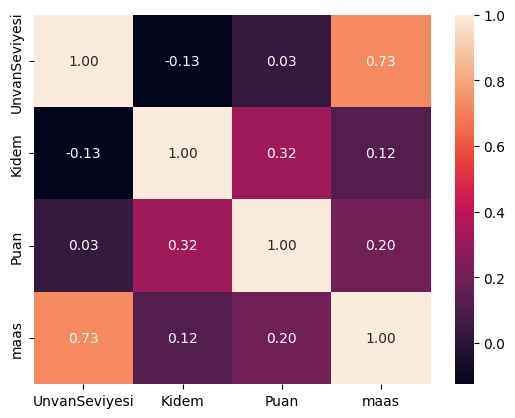

In [5]:
corr_df = df.corr() 
sns.heatmap(corr_df,annot=True,fmt=".2f") 

,F_Score,P_Value
UnvanSeviyesi,31.395167,0.000005
Kidem,0.395131,0.534709
Puan,1.184651,0.285691


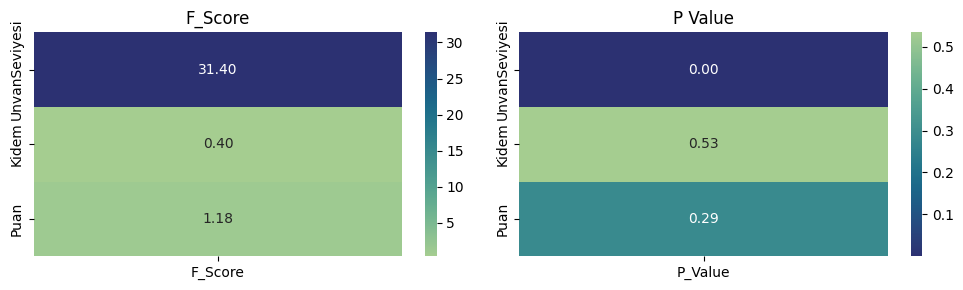

In [6]:
from sklearn.feature_selection import f_regression

X = df.drop(columns=["maas"],axis=1) 
Y = df["maas"] 

anova_df , p_val_df = f_regression(X,Y)

anova_table = pd.DataFrame({
    'F_Score':anova_df,
    'P_Value':p_val_df
},index=X.columns) 

anova_table.sort_values(by="F_Score",ascending=False) 

fig , ax = plt.subplots(1,2,figsize=(10,3)) 

sns.heatmap(anova_table[["F_Score"]],annot=True,ax=ax[0],fmt=".2f", cmap="crest",) 
ax[0].set_title("F_Score") 

sns.heatmap(anova_table[["P_Value"]],annot=True,ax=ax[1],fmt=".2f", cmap="crest_r",) 
ax[1].set_title("P Value") 

plt.tight_layout()

anova_table 

In [7]:
df.head(1)

,UnvanSeviyesi,Kidem,Puan,maas
Calisan ID,,,,
1,1,5,70,2250


In [8]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler , PolynomialFeatures

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,train_size=0.75,random_state=0) 

sc = StandardScaler() 

x_train_sc = sc.fit_transform(X_train) 
x_test_sc = sc.transform(X_test) 

In [10]:
lr = LinearRegression() 

model = lr.fit(x_train_sc,Y_train) 

predict = model.predict(x_test_sc) 

r2_scores = r2_score(predict,Y_test) 

ceo_predicts = model.predict([[10,10,100]])[0]
manager_predicts = model.predict([[7,10,100]])[0]

print(f"LinearRegression R2 Scores: {r2_scores}") 

print(f"Tahmini CEO Maaşı: {ceo_predicts:.2f}") 
print(f"Tahmini Müdür Maaşı: {manager_predicts:.2f}")

LinearRegression R2 Scores: 0.2629664963476872
Tahmini CEO Maaşı: 227007.77
Tahmini Müdür Maaşı: 192257.52


In [11]:
polyr = PolynomialFeatures(degree=2) 

X_train_poly = polyr.fit_transform(X_train) 
X_test_poly = polyr.transform(X_test) 

lr_poly = LinearRegression() 

poly_model = lr_poly.fit(X_train_poly,Y_train) 

poly_scores = poly_model.score(X_test_poly, Y_test)

ceo_poly_predicts = poly_model.predict(polyr.transform([[10,10,100]]))[0] 
manager_poly_predicts = poly_model.predict(polyr.transform([[7,10,100]]))[0] 

print(f"Polinomal Regressyon R2 Scores: {poly_scores}")

print(f"Tahmini CEO Maaşı: {ceo_poly_predicts:.2f}") 
print(f"Tahmini Müdür Maaşı: {manager_poly_predicts:.2f}") 

Polinomal Regressyon R2 Scores: -3.0168352473795252
Tahmini CEO Maaşı: 66714.00
Tahmini Müdür Maaşı: 30523.36


In [12]:
from sklearn.svm import SVR

parameters = {
    "C":[1,10,1000,1000],
    "gamma":[1,0.1,0.01,0.001],
    "kernel":["rbf","linear","poly"] 
}

svr_reg = GridSearchCV(estimator=SVR(),param_grid=parameters,cv=5) 
svr_reg.fit(x_train_sc,Y_train) 
svr_reg.best_params_

svr_predicts = svr_reg.predict(x_test_sc) 

svr_r2_scores = r2_score(svr_predicts,Y_test) 

ceo_svr_predicts = svr_reg.predict([[10,10,100]])[0] 
manager_svr_predicts = svr_reg.predict([[7,10,100]])[0]

print(f"SVR R2 Scores: {svr_r2_scores}") 

print(f"Tahmini CEO Maaşı: {ceo_svr_predicts:.2f}") 
print(f"Tahmini Müdür Maaşı: {manager_svr_predicts:.2f}") 

SVR R2 Scores: 0.6445690771858061
Tahmini CEO Maaşı: 81598.06
Tahmini Müdür Maaşı: 68264.20


DecisionTreeRegressor R2 Score: 0.8028820239442185
Tahmini CEO Maaşı: 44000.00
Tahmini Müdür Maaşı: 12000.00


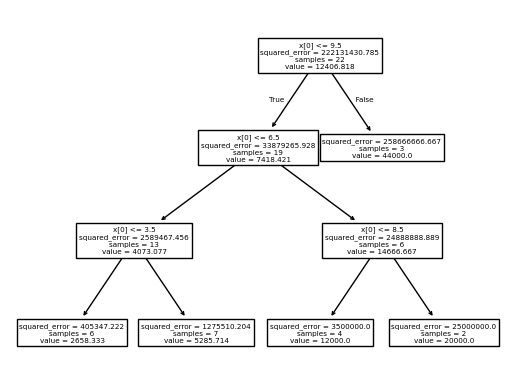

In [16]:
from sklearn.tree import DecisionTreeRegressor , plot_tree

des_tree = DecisionTreeRegressor(max_depth=3,min_samples_leaf=2,random_state=0) 

model = des_tree.fit(X_train,Y_train) 

predict = model.predict(X_test) 

des_tree_r2_scores = r2_score(Y_test,predict) 

ceo_tree_predict = model.predict([[10,10,100]])[0] 
manager_tree_predict = model.predict([[7,10,100]])[0] 

print(f"DecisionTreeRegressor R2 Score: {des_tree_r2_scores}") 

print(f"Tahmini CEO Maaşı: {ceo_tree_predict:.2f}") 
print(f"Tahmini Müdür Maaşı: {manager_tree_predict:.2f}") 

plot_tree(des_tree);

In [14]:
from sklearn.ensemble import RandomForestRegressor 

forest = RandomForestRegressor(n_estimators=200,max_depth=3,min_samples_leaf=2,random_state=0) 

model = forest.fit(X_train,Y_train) 

predict = model.predict(X_test) 

forest_r2_scores = r2_score(Y_test,predict) 

ceo_forest_predict = model.predict([[10,10,100]])[0] 
manager_forest_predict = model.predict([[7,10,100]])[0] 

print(f"Random Forrest R2 Scores: {forest_r2_scores}") 

print(f"Tahmini CEO Maaşı: {ceo_forest_predict:.2f}") 
print(f"Tahmini Müdür Maaşı: {manager_forest_predict:.2f}") 

Random Forrest R2 Scores: 0.6052391017859254
Tahmini CEO Maaşı: 38199.62
Tahmini Müdür Maaşı: 10833.71


In [15]:
salary_df = pd.DataFrame({
    "CEO Predict Salaries ":[ceo_predicts,ceo_poly_predicts,ceo_svr_predicts,ceo_tree_predict,ceo_forest_predict],
    "Manager Predict Salaries":[manager_predicts,manager_poly_predicts,manager_svr_predicts,manager_tree_predict,manager_forest_predict]
},index=["Linear Regression Predicts","Polynomial Regression Predicts","SVR Predicts","Decision Tree Predicts","Random Forrest Predicts"]).T 

salary_df

,Linear Regression Predicts,Polynomial Regression Predicts,SVR Predicts,Decision Tree Predicts,Random Forrest Predicts
CEO Predict Salaries,227007.770702,66713.995539,81598.063388,44000.0,38199.625000
Manager Predict Salaries,192257.522506,30523.363285,68264.198423,12000.0,10833.709145


In [17]:
r2_df = pd.DataFrame({
    "r2_scores":[r2_scores,poly_scores,svr_r2_scores,des_tree_r2_scores,forest_r2_scores]
},index=["Linear Regression R2 Scores","Polynomial Regression R2 Scores","SVR R2 Scores","Decision Tree R2 Scores","Random Forrest R2 Scores"]) 

r2_df

,r2_scores
Linear Regression R2 Scores,0.262966
Polynomial Regression R2 Scores,-3.016835
SVR R2 Scores,0.644569
Decision Tree R2 Scores,0.802882
Random Forrest R2 Scores,0.605239
